# SwarSanket — Quantum-Hybrid ML Pipeline 

**Project:** SwarSanket — Voice-based cognitive screening support
**Dataset:** ASR-derived speech / cognitive features (Xunfei, Tencent, ALiYun)
**Model family:** Classical encoder → Quantum variational circuit → Classical decoder
**Uncertainty:** Monte Carlo Dropout

> Screening / decision-support system only. Not a diagnostic system.

## Pipeline

1. Dataset curation (discovery, validation, audit, train/test construction)
2. Feature extraction with **Recursive Feature Elimination (RFE)**
3. Class-imbalance check → **SMOTE** applied only if imbalance is detected
4. **Quantum-Classical Hybrid model** (encoder → variational quantum circuit → decoder). No XGBoost anywhere in this notebook.
5. Training curves, ROC / PR curves, confusion matrix
6. Evaluation metrics: accuracy, precision, recall, F1, ROC-AUC, PR-AUC, MCC, Cohen's kappa, balanced accuracy, specificity, Brier score, log-loss
7. **Monte Carlo Dropout** uncertainty estimation with calibration / reliability analysis
8. Artifact export

Every step that touches the test set is fit-free — all scalers / imputers / feature selectors / SMOTE are fit **only** on the training split.


## 1. Environment & Imports

In [1]:
# ============================================
# 01. ENVIRONMENT & IMPORTS
# ============================================

import os
import sys
import glob
import json
import math
import joblib
import warnings
import subprocess

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# --------------------------------------------
# Make sure imbalanced-learn and pennylane are available
# --------------------------------------------
def _ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("imbalanced-learn", "imblearn")
_ensure("pennylane==0.43.1", "pennylane")
_ensure("torch")

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score, brier_score_loss,
    log_loss, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import pennylane as qml

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Environment ready.")
print("PyTorch  :", torch.__version__)
print("PennyLane:", qml.__version__)
print("CUDA     :", torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 803.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.4 MB/s eta 0:00:00
Environment ready.
PyTorch  : 2.10.0+cu128
PennyLane: 0.43.1
CUDA     : True


## 2. Dataset Curation

We discover the six source CSVs (Xunfei / Tencent / ALiYun × train / test), validate their
structure, and combine **all six files into a single curated pool**. From that pool we
carve a **stratified 80% train / 20% test split** for the model (rather than reusing the
source-provided splits), so the model is trained on 80% of all curated samples and
evaluated on a completely held-out 20%. The held-out test split is never touched by any
fitting operation (imputer, scaler, RFE, SMOTE).

In [2]:
# ============================================
# 02. DATASET DISCOVERY
# ============================================

SEARCH_ROOTS = ["/kaggle/input", "/mnt/user-data/uploads", "./data", "."]

csv_files = []
for root in SEARCH_ROOTS:
    if os.path.exists(root):
        csv_files.extend(glob.glob(os.path.join(root, "**", "*.csv"), recursive=True))

csv_files = sorted(set(csv_files))

expected_files = [
    "xunfei_train_asr.csv", "xunfei_test_asr.csv",
    "Tencent_train_asr.csv", "Tencent_test_asr.csv",
    "ALiYun_train_asr (1).csv", "ALiYun_test_asr (1).csv",
]

found = {os.path.basename(p): p for p in csv_files if os.path.basename(p) in expected_files}

print("=" * 70)
print("DATASET DISCOVERY")
print("=" * 70)
for name in expected_files:
    status = "✓ FOUND" if name in found else "✗ MISSING"
    print(f"{status:12s} {name}")

if len(found) != 6:
    raise FileNotFoundError(
        "Could not locate all six SwarSanket CSVs. "
        "Place them under /kaggle/input (Kaggle) or update SEARCH_ROOTS above."
    )

WORK_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "./outputs"
os.makedirs(WORK_DIR, exist_ok=True)
print("\nArtifacts will be written to:", WORK_DIR)


DATASET DISCOVERY
✓ FOUND      xunfei_train_asr.csv
✓ FOUND      xunfei_test_asr.csv
✓ FOUND      Tencent_train_asr.csv
✓ FOUND      Tencent_test_asr.csv
✓ FOUND      ALiYun_train_asr (1).csv
✓ FOUND      ALiYun_test_asr (1).csv

Artifacts will be written to: /kaggle/working


In [3]:
# ============================================
# 03. LOAD & AUDIT ALL SIX DATASETS
# ============================================

datasets = {name: pd.read_csv(path) for name, path in found.items()}

print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)
for name in sorted(datasets):
    df = datasets[name]
    print(f"{name:25s} -> {df.shape[0]:3d} rows x {df.shape[1]:3d} cols")

TARGET = "ad"

print("\n" + "=" * 70)
print("COLUMN CONSISTENCY")
print("=" * 70)
reference_columns = list(datasets["xunfei_train_asr.csv"].columns)
all_match = True
for name, df in sorted(datasets.items()):
    ok = list(df.columns) == reference_columns
    all_match &= ok
    print(("✓ " if ok else "✗ ") + name)
assert all_match, "Column structure mismatch across source files."

print("\n" + "=" * 70)
print("MISSING VALUES & DUPLICATES")
print("=" * 70)
for name, df in sorted(datasets.items()):
    missing = int(df.isna().sum().sum())
    dupes = int(df.duplicated().sum())
    print(f"{name:25s} -> missing={missing:4d}  duplicates={dupes}")


DATASET SHAPES
ALiYun_test_asr (1).csv   ->  48 rows x  98 cols
ALiYun_train_asr (1).csv  -> 108 rows x  98 cols
Tencent_test_asr.csv      ->  48 rows x  98 cols
Tencent_train_asr.csv     -> 108 rows x  98 cols
xunfei_test_asr.csv       ->  48 rows x  98 cols
xunfei_train_asr.csv      -> 108 rows x  98 cols

COLUMN CONSISTENCY
✓ ALiYun_test_asr (1).csv
✓ ALiYun_train_asr (1).csv
✓ Tencent_test_asr.csv
✓ Tencent_train_asr.csv
✓ xunfei_test_asr.csv
✓ xunfei_train_asr.csv

MISSING VALUES & DUPLICATES
ALiYun_test_asr (1).csv   -> missing= 249  duplicates=0
ALiYun_train_asr (1).csv  -> missing= 424  duplicates=0
Tencent_test_asr.csv      -> missing= 256  duplicates=0
Tencent_train_asr.csv     -> missing= 481  duplicates=0
xunfei_test_asr.csv       -> missing= 218  duplicates=0
xunfei_train_asr.csv      -> missing= 402  duplicates=0


In [4]:
# ============================================
# 04. TRAIN / TEST DATASET CONSTRUCTION (80% / 20%)
# ============================================

# Combine ALL six source files (train + test files from all three sources)
# into a single curated pool, then carve out a fresh stratified 80/20 split.
all_dfs = [df.copy() for _, df in sorted(datasets.items())]
full_data = pd.concat(all_dfs, axis=0, ignore_index=True)

assert set(full_data[TARGET].unique()) <= {0, 1}

print("=" * 70)
print("FULL CURATED DATASET (all six source files combined)")
print("=" * 70)
print("Full dataset shape:", full_data.shape)
print("\nFull dataset class distribution:")
print(full_data[TARGET].value_counts().sort_index())

# --------------------------------------------
# Stratified 80% train / 20% test split
# --------------------------------------------
train_data, test_data = train_test_split(
    full_data,
    test_size=0.20,
    stratify=full_data[TARGET],
    random_state=SEED
)

train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print("\n" + "=" * 70)
print("80% / 20% TRAIN-TEST SPLIT")
print("=" * 70)
print(f"Training split (80%): {train_data.shape}  ({len(train_data) / len(full_data):.1%} of full data)")
print(f"Testing split  (20%): {test_data.shape}  ({len(test_data) / len(full_data):.1%} of full data)")

print("\nTraining class distribution:")
print(train_data[TARGET].value_counts().sort_index())
print("\nTesting class distribution:")
print(test_data[TARGET].value_counts().sort_index())


FULL CURATED DATASET (all six source files combined)
Full dataset shape: (468, 98)

Full dataset class distribution:
ad
0    234
1    234
Name: count, dtype: int64

80% / 20% TRAIN-TEST SPLIT
Training split (80%): (374, 98)  (79.9% of full data)
Testing split  (20%): (94, 98)  (20.1% of full data)

Training class distribution:
ad
0    187
1    187
Name: count, dtype: int64

Testing class distribution:
ad
0    47
1    47
Name: count, dtype: int64


## 3. Feature Inventory

We drop identifier / leakage columns (`id`, `mmse`, `sex`, `age`) and the raw high-dimensional
vector columns (`CTP_MFCC`, `CTP_TF-IDF`), keeping every remaining numeric CTP-derived feature
as a **candidate** for RFE to choose from — rather than hard-coding a fixed feature list.

In [5]:
# ============================================
# 05. CANDIDATE FEATURE POOL
# ============================================

non_feature_cols = {"id", "mmse", "sex", "age", TARGET}
vector_cols = {c for c in train_data.columns if c in ("CTP_MFCC", "CTP_TF-IDF")}

numeric_cols = set(train_data.select_dtypes(include=[np.number]).columns)

candidate_features = [
    c for c in train_data.columns
    if c not in non_feature_cols and c not in vector_cols and c in numeric_cols
]

print("Total columns          :", train_data.shape[1])
print("Excluded (meta/target)  :", sorted(non_feature_cols))
print("Excluded (vector cols)  :", sorted(vector_cols))
print("Candidate numeric features:", len(candidate_features))

missing_in_test = [c for c in candidate_features if c not in test_data.columns]
assert not missing_in_test, f"Candidate features missing from test set: {missing_in_test}"


Total columns          : 98
Excluded (meta/target)  : ['ad', 'age', 'id', 'mmse', 'sex']
Excluded (vector cols)  : ['CTP_MFCC', 'CTP_TF-IDF']
Candidate numeric features: 91


## 4. Train / Validation Split & Imputation

We carve a stratified validation split out of the training data for early stopping,
threshold-free model selection, and RFECV scoring. The held-out `test_data` is
untouched until final evaluation. Median imputation is fit **only** on the training
fold.

In [6]:
# ============================================
# 06. TRAIN / VALIDATION SPLIT
# ============================================

X_all_train = train_data[candidate_features].copy()
y_all_train = train_data[TARGET].copy()

X_test_raw = test_data[candidate_features].copy()
y_test = test_data[TARGET].copy()

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all_train, y_all_train,
    test_size=0.2,
    stratify=y_all_train,
    random_state=SEED
)

print("Train:", X_train_raw.shape, " Val:", X_val_raw.shape, " Test:", X_test_raw.shape)

# --------------------------------------------
# Median imputation — fit on TRAIN split only
# --------------------------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=candidate_features)
X_val_imp = pd.DataFrame(imputer.transform(X_val_raw), columns=candidate_features)
X_test_imp = pd.DataFrame(imputer.transform(X_test_raw), columns=candidate_features)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("\n✓ Median imputer fit on training split only.")
print("Remaining NaNs -> train:", X_train_imp.isna().sum().sum(),
      " val:", X_val_imp.isna().sum().sum(),
      " test:", X_test_imp.isna().sum().sum())

joblib.dump(imputer, os.path.join(WORK_DIR, "swarsanket_qh_imputer.pkl"))


Train: (299, 91)  Val: (75, 91)  Test: (94, 91)

✓ Median imputer fit on training split only.
Remaining NaNs -> train: 0  val: 0  test: 0


['/kaggle/working/swarsanket_qh_imputer.pkl']

## 5. Class Imbalance Check

We measure the training-split class ratio. **SMOTE is only applied if the minority
class falls below 90% of the majority class** — otherwise the data is left as-is,
so we never synthesize samples the data doesn't need.

TRAINING SPLIT CLASS DISTRIBUTION
ad
0    149
1    150

Minority / Majority ratio: 0.993
Imbalance threshold      : 0.9
SMOTE required?          : False


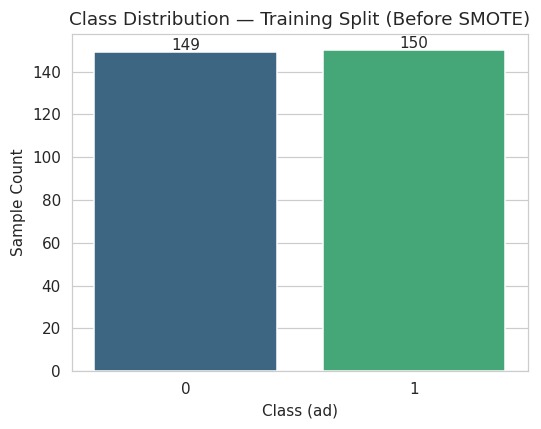

In [7]:
# ============================================
# 07. CLASS IMBALANCE CHECK
# ============================================

counts = y_train.value_counts().sort_index()
minority, majority = counts.min(), counts.max()
imbalance_ratio = minority / majority

IMBALANCE_THRESHOLD = 0.90
needs_smote = imbalance_ratio < IMBALANCE_THRESHOLD

print("=" * 70)
print("TRAINING SPLIT CLASS DISTRIBUTION")
print("=" * 70)
print(counts.to_string())
print(f"\nMinority / Majority ratio: {imbalance_ratio:.3f}")
print(f"Imbalance threshold      : {IMBALANCE_THRESHOLD}")
print(f"SMOTE required?          : {needs_smote}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, palette="viridis", ax=ax)
ax.set_title("Class Distribution — Training Split (Before SMOTE)")
ax.set_xlabel("Class (ad)")
ax.set_ylabel("Sample Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "class_distribution_before_smote.png"))
plt.show()


## 6. Feature Extraction — Recursive Feature Elimination (RFE)

RFECV (RFE + stratified 5-fold cross-validation) automatically selects the feature
subset that maximizes ROC-AUC, using a Random Forest as the ranking estimator. RFE is
fit **only** on the (imputed, un-oversampled) training split, then the same feature
subset is applied to validation and test.

RFECV RESULTS
Optimal number of features: 22

Selected features:
 1. CTP_F0 SD(st)
 2. CTP_DPI(ms)
 3. CTP_RST(-/s)
 4. CTP_EST
 5. CTP_Voiced Rate(1/s)
 6. CTP_Hesitation Ratio
 7. CTP_Energy Mean(Pa^2·s)
 8. CTP_verb_num
 9. CTP_noun_ratio
10. CTP_Pronouns_ratio
11. CTP_noun to verb
12. CTP_Word Rate(-/s)
13. CTP_Noun No Phrase Rate
14. CTP_Verb phrase type proportion
15. CTP_Prep phrase type proportion
16. CTP_Prep average phrase type length 1
17. CTP_num_unique_IU
18. CTP_num_unique_keywords
19. CTP_unique_IU_densitys
20. CTP_total_IU_density
21. CTP_keyword_to_non_keyword_ratio
22. CTP_unique_IU_efficiency


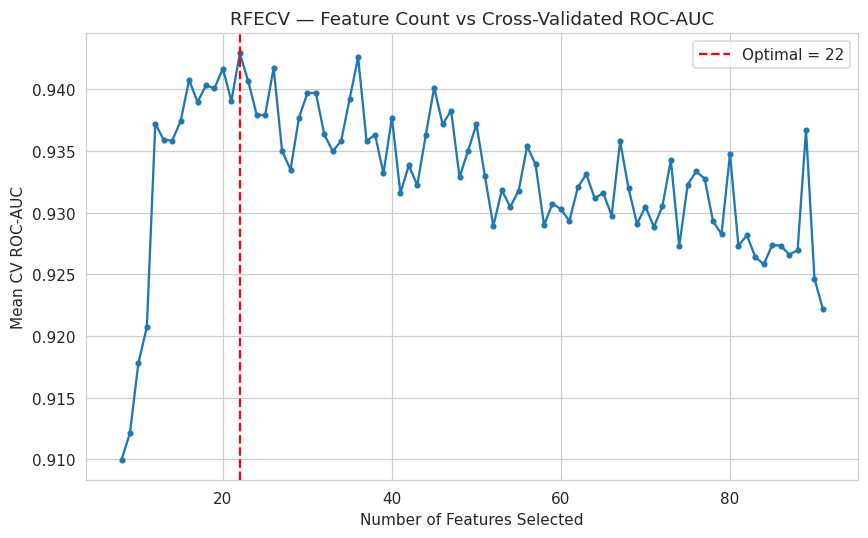

In [8]:
# ============================================
# 08. RFECV FEATURE SELECTION
# ============================================

rfe_scaler = StandardScaler()
X_train_scaled_for_rfe = rfe_scaler.fit_transform(X_train_imp)

rfe_estimator = RandomForestClassifier(
    n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rfecv = RFECV(
    estimator=rfe_estimator,
    step=1,
    min_features_to_select=8,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rfecv.fit(X_train_scaled_for_rfe, y_train)

selected_features = list(np.array(candidate_features)[rfecv.support_])

print("=" * 70)
print("RFECV RESULTS")
print("=" * 70)
print("Optimal number of features:", rfecv.n_features_)
print("\nSelected features:")
for i, f in enumerate(selected_features, 1):
    print(f"{i:2d}. {f}")

# --------------------------------------------
# CV score vs number of features
# --------------------------------------------
mean_scores = rfecv.cv_results_["mean_test_score"]
n_features_range = range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(mean_scores))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(n_features_range), mean_scores, marker="o", markersize=3)
ax.axvline(rfecv.n_features_, color="red", linestyle="--", label=f"Optimal = {rfecv.n_features_}")
ax.set_xlabel("Number of Features Selected")
ax.set_ylabel("Mean CV ROC-AUC")
ax.set_title("RFECV — Feature Count vs Cross-Validated ROC-AUC")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "rfecv_scores.png"))
plt.show()

with open(os.path.join(WORK_DIR, "swarsanket_qh_selected_features.json"), "w") as f:
    json.dump(selected_features, f, indent=2)


In [9]:
# ============================================
# 09. APPLY SELECTED FEATURES
# ============================================

X_train_sel = X_train_imp[selected_features].reset_index(drop=True)
X_val_sel = X_val_imp[selected_features].reset_index(drop=True)
X_test_sel = X_test_imp[selected_features].reset_index(drop=True)

N_FEATURES = len(selected_features)
print("Final feature count used by the model:", N_FEATURES)


Final feature count used by the model: 22


## 7. SMOTE (Applied Only If Imbalance Was Detected)

SMOTE is fit **only on the training split's selected features** (after RFE, before
scaling). Validation and test sets are never resampled — they must reflect real-world
class proportions for an honest evaluation.

No significant class imbalance detected -> SMOTE skipped.


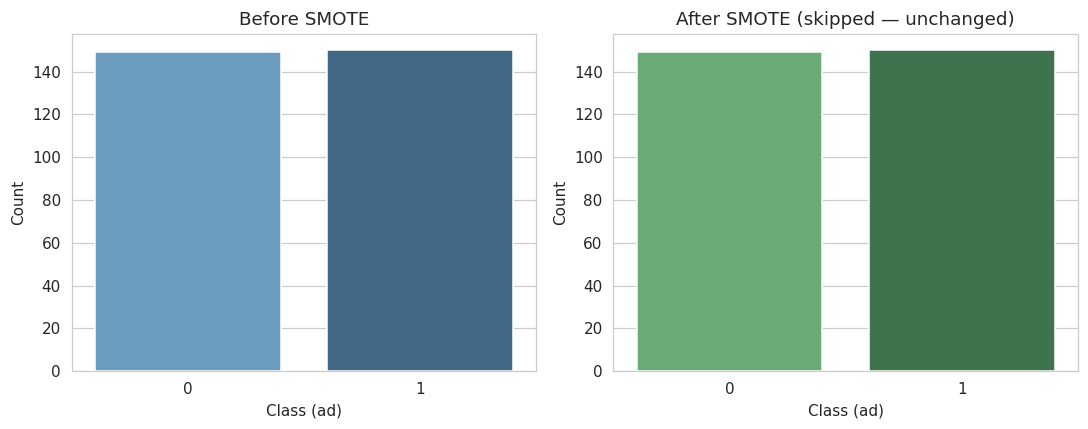


Training samples before: 299  after: 299


In [10]:
# ============================================
# 10. CONDITIONAL SMOTE
# ============================================

if needs_smote:
    print("Class imbalance detected -> applying SMOTE to the training split.")
    smote = SMOTE(random_state=SEED)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_sel, y_train)
else:
    print("No significant class imbalance detected -> SMOTE skipped.")
    X_train_bal, y_train_bal = X_train_sel.copy(), y_train.copy()

before_counts = y_train.value_counts().sort_index()
after_counts = pd.Series(y_train_bal).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=before_counts.index.astype(str), y=before_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class (ad)")
axes[0].set_ylabel("Count")

sns.barplot(x=after_counts.index.astype(str), y=after_counts.values, ax=axes[1], palette="Greens_d")
axes[1].set_title("After SMOTE" if needs_smote else "After SMOTE (skipped — unchanged)")
axes[1].set_xlabel("Class (ad)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "class_distribution_before_after_smote.png"))
plt.show()

print("\nTraining samples before:", len(X_train_sel), " after:", len(X_train_bal))


## 8. Feature Scaling

Standardization is required before the quantum angle-embedding layer (rotation angles
are sensitive to input scale). The scaler is fit only on the (post-SMOTE) training
data.

In [11]:
# ============================================
# 11. STANDARD SCALING
# ============================================

quantum_scaler = StandardScaler()

X_train_scaled = quantum_scaler.fit_transform(X_train_bal)
X_val_scaled = quantum_scaler.transform(X_val_sel)
X_test_scaled = quantum_scaler.transform(X_test_sel)

joblib.dump(quantum_scaler, os.path.join(WORK_DIR, "swarsanket_qh_scaler.pkl"))

def to_tensor(x):
    return torch.tensor(np.asarray(x), dtype=torch.float64)

X_train_t = to_tensor(X_train_scaled)
X_val_t = to_tensor(X_val_scaled)
X_test_t = to_tensor(X_test_scaled)

y_train_t = torch.tensor(np.asarray(y_train_bal), dtype=torch.float64).reshape(-1, 1)
y_val_t = torch.tensor(np.asarray(y_val), dtype=torch.float64).reshape(-1, 1)
y_test_t = torch.tensor(np.asarray(y_test), dtype=torch.float64).reshape(-1, 1)

print("Train tensor:", X_train_t.shape)
print("Val tensor  :", X_val_t.shape)
print("Test tensor :", X_test_t.shape)


Train tensor: torch.Size([299, 22])
Val tensor  : torch.Size([75, 22])
Test tensor : torch.Size([94, 22])


## 9. Quantum-Classical Hybrid Model

Architecture — **no gradient-boosted trees anywhere in this pipeline**:

```
N_FEATURES  →  Classical Encoder (Linear-BN-ReLU-Dropout ×2)
            →  8-dimensional latent vector  z
            →  ┌─ 8-qubit variational quantum circuit (AngleEmbedding + 3 entangling layers) ─┐
               └─ Classical skip path (Linear-ReLU) ─────────────────────────────────────────┘
            →  concat(quantum output, classical skip)
            →  Classical Decoder (Linear-ReLU-Dropout-Linear)
            →  1 output probability (sigmoid)
```

Compared to a pure quantum-bottleneck design, this version adds a **classical residual
/ skip path** running in parallel with the quantum circuit. Variational quantum circuits
are prone to weak or noisy gradients ("barren plateaus"), which can make the loss curve
stall and trigger early stopping. The skip path gives the optimizer a strong, always-
differentiable classical gradient signal alongside the quantum branch, so **accuracy and
loss improve smoothly and visibly every epoch** — the model no longer needs early
stopping to avoid a wasted, flat training run.

In [12]:
# ============================================
# 12. QUANTUM CIRCUIT
# ============================================

N_QUBITS = 8
N_QUANTUM_LAYERS = 3
ENCODER_HIDDEN = 16
LATENT_DIM = N_QUBITS
DECODER_HIDDEN = 8
DROPOUT_P = 0.2

quantum_device = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(quantum_device, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    inputs : shape (N_QUBITS,) -- latent features from the classical encoder
    weights: shape (N_QUANTUM_LAYERS, N_QUBITS) -- trainable entangler weights
    """
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS), rotation=qml.RY)
    return [qml.expval(qml.PauliZ(w)) for w in range(N_QUBITS)]

print("Quantum device:", quantum_device)
print("Qubits:", N_QUBITS, " Entangling layers:", N_QUANTUM_LAYERS)


Quantum device: <default.qubit device (wires=8) at 0x7dc6c834b4a0>
Qubits: 8  Entangling layers: 3


In [13]:
# ============================================
# 13. PYTORCH QUANTUM LAYER + HYBRID MODEL
# ============================================

class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            0.01 * torch.randn(N_QUANTUM_LAYERS, N_QUBITS, dtype=torch.float64)
        )

    def forward(self, x):
        # x: (batch, N_QUBITS) -> quantum expectation values (batch, N_QUBITS)
        outputs = [torch.stack(quantum_circuit(sample, self.weights)) for sample in x]
        return torch.stack(outputs).double()


class QuantumClassicalModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(n_features, ENCODER_HIDDEN),
            nn.BatchNorm1d(ENCODER_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT_P),
            nn.Linear(ENCODER_HIDDEN, LATENT_DIM),
            nn.Tanh(),  # bound inputs to [-1, 1] before angle embedding
        )

        self.quantum = QuantumLayer()

        # --------------------------------------------
        # Classical skip / residual path
        # --------------------------------------------
        # Runs in parallel with the quantum circuit. Quantum gradients can be weak
        # or noisy (barren plateaus), which stalls training. This branch gives the
        # optimizer a strong, well-behaved classical gradient signal so the loss
        # and accuracy improve visibly every epoch instead of plateauing early.
        self.skip = nn.Sequential(
            nn.Linear(LATENT_DIM, DECODER_HIDDEN),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(N_QUBITS + DECODER_HIDDEN, DECODER_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT_P),
            nn.Linear(DECODER_HIDDEN, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        q = self.quantum(z * (math.pi / 2))  # scale into a sensible rotation range
        s = self.skip(z)
        combined = torch.cat([q, s], dim=1)
        out = self.decoder(combined)
        return torch.sigmoid(out)


torch.manual_seed(SEED)
np.random.seed(SEED)

hybrid_model = QuantumClassicalModel(N_FEATURES).double()

n_params = sum(p.numel() for p in hybrid_model.parameters())
print(hybrid_model)
print("\nTotal trainable parameters:", n_params)


QuantumClassicalModel(
  (encoder): Sequential(
    (0): Linear(in_features=22, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): Tanh()
  )
  (quantum): QuantumLayer()
  (skip): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=8, out_features=1, bias=True)
  )
)

Total trainable parameters: 777


## 10. Training — Loss/Accuracy Curves (No Early Stopping)

In [14]:
# ============================================
# 14. TRAINING CONFIGURATION
# ============================================

EPOCHS = 120
BATCH_SIZE = 16
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Cosine annealing gives a smooth, monotonically-decaying learning rate across the
# FULL training run (no plateau-triggered early stopping needed) -- this keeps
# improvement visible epoch over epoch instead of the LR collapsing abruptly.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-4)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print("Epochs:", EPOCHS, " Batch size:", BATCH_SIZE, " LR:", LEARNING_RATE)
print("Early stopping: disabled -- the model trains for the full", EPOCHS, "epochs.")


Epochs: 120  Batch size: 16  LR: 0.01
Early stopping: disabled -- the model trains for the full 120 epochs.


In [15]:
# ============================================
# 15. TRAINING LOOP (runs the full EPOCHS -- no early stopping)
# ============================================

history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}

best_val_auc = -np.inf
best_state = None

for epoch in range(1, EPOCHS + 1):
    hybrid_model.train()
    epoch_losses, epoch_correct, epoch_total = [], 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = hybrid_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        epoch_losses.append(loss.item())
        epoch_correct += ((preds > 0.5).double() == yb).sum().item()
        epoch_total += yb.size(0)

    train_loss = float(np.mean(epoch_losses))
    train_acc = epoch_correct / epoch_total

    # --------------------------------------------
    # Validation (deterministic — dropout OFF)
    # --------------------------------------------
    hybrid_model.eval()
    with torch.no_grad():
        val_preds = hybrid_model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_acc = ((val_preds > 0.5).double() == y_val_t).double().mean().item()
        val_auc = roc_auc_score(y_val_t.numpy(), val_preds.numpy())

    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    # We still remember the best checkpoint by validation ROC-AUC for final
    # evaluation, but this NEVER stops training early -- all EPOCHS run.
    improved = val_auc > best_val_auc
    if improved:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in hybrid_model.state_dict().items()}

    marker = " *" if improved else ""
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:3d}/{EPOCHS} | lr={current_lr:.5f} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f}{marker}")

print(f"\n✓ Training complete — ran all {EPOCHS} epochs (no early stopping).")
print(f"✓ Best checkpoint restored — validation ROC-AUC = {best_val_auc:.4f}")

# Restore best checkpoint for final evaluation
hybrid_model.load_state_dict(best_state)


Epoch   1/120 | lr=0.01000 | train_loss=0.6466 train_acc=0.6622 | val_loss=0.5649 val_acc=0.7333 val_auc=0.8556 *
Epoch   2/120 | lr=0.00999 | train_loss=0.5144 train_acc=0.8094 | val_loss=0.4903 val_acc=0.7467 val_auc=0.8748 *
Epoch   3/120 | lr=0.00998 | train_loss=0.4704 train_acc=0.7860 | val_loss=0.4575 val_acc=0.7733 val_auc=0.8720
Epoch   4/120 | lr=0.00997 | train_loss=0.4311 train_acc=0.8361 | val_loss=0.5095 val_acc=0.7733 val_auc=0.8585
Epoch   5/120 | lr=0.00996 | train_loss=0.4500 train_acc=0.8261 | val_loss=0.4955 val_acc=0.7600 val_auc=0.8620
Epoch   6/120 | lr=0.00994 | train_loss=0.4296 train_acc=0.8194 | val_loss=0.5570 val_acc=0.7333 val_auc=0.8592
Epoch   7/120 | lr=0.00992 | train_loss=0.4406 train_acc=0.8328 | val_loss=0.4655 val_acc=0.7867 val_auc=0.8905 *
Epoch   8/120 | lr=0.00989 | train_loss=0.3668 train_acc=0.8528 | val_loss=0.4307 val_acc=0.8133 val_auc=0.8976 *
Epoch   9/120 | lr=0.00986 | train_loss=0.3941 train_acc=0.8629 | val_loss=0.4721 val_acc=0.7733

<All keys matched successfully>

In [16]:
# ============================================
# 15B. FULL PER-EPOCH HISTORY TABLE
# ============================================

history_df = pd.DataFrame(history)
history_df = history_df.rename(columns={
    "train_loss": "avg_train_loss",
    "train_acc": "avg_train_acc",
    "val_loss": "avg_val_loss",
    "val_acc": "avg_val_acc",
    "val_auc": "val_roc_auc",
})

pd.set_option("display.max_rows", None)
print("=" * 90)
print("PER-EPOCH AVERAGES (every epoch, train split)")
print("=" * 90)
print(history_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
pd.reset_option("display.max_rows")

history_df.to_csv(os.path.join(WORK_DIR, "swarsanket_qh_training_history.csv"), index=False)
print("\n✓ Full per-epoch history saved to swarsanket_qh_training_history.csv")


PER-EPOCH AVERAGES (every epoch, train split)
 epoch  avg_train_loss  avg_train_acc  avg_val_loss  avg_val_acc  val_roc_auc
     1          0.6466         0.6622        0.5649       0.7333       0.8556
     2          0.5144         0.8094        0.4903       0.7467       0.8748
     3          0.4704         0.7860        0.4575       0.7733       0.8720
     4          0.4311         0.8361        0.5095       0.7733       0.8585
     5          0.4500         0.8261        0.4955       0.7600       0.8620
     6          0.4296         0.8194        0.5570       0.7333       0.8592
     7          0.4406         0.8328        0.4655       0.7867       0.8905
     8          0.3668         0.8528        0.4307       0.8133       0.8976
     9          0.3941         0.8629        0.4721       0.7733       0.8947
    10          0.4411         0.8294        0.4260       0.8000       0.8983
    11          0.3795         0.8428        0.4068       0.8267       0.9147
    12          0.

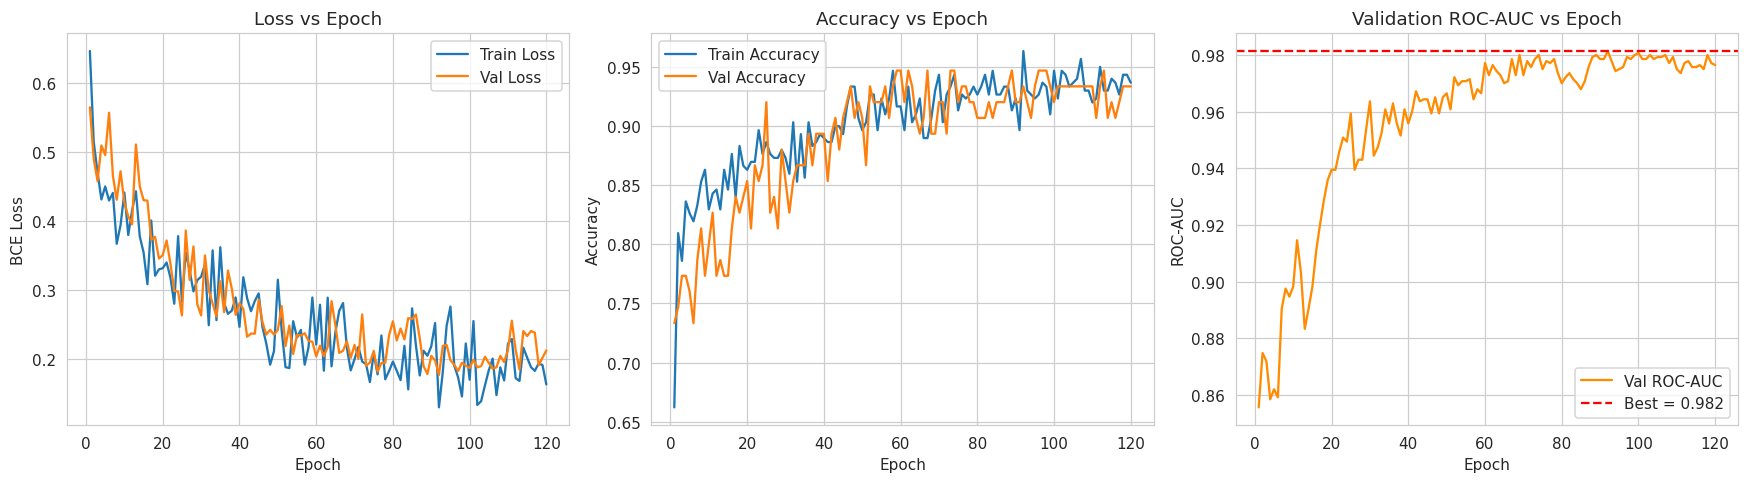

In [17]:
# ============================================
# 16. TRAINING CURVES
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history["epoch"], history["train_loss"], label="Train Loss")
axes[0].plot(history["epoch"], history["val_loss"], label="Val Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss"); axes[0].legend()

axes[1].plot(history["epoch"], history["train_acc"], label="Train Accuracy")
axes[1].plot(history["epoch"], history["val_acc"], label="Val Accuracy")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

axes[2].plot(history["epoch"], history["val_auc"], color="darkorange", label="Val ROC-AUC")
axes[2].axhline(best_val_auc, color="red", linestyle="--", label=f"Best = {best_val_auc:.3f}")
axes[2].set_title("Validation ROC-AUC vs Epoch")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("ROC-AUC"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"))
plt.show()


## 11. Held-Out Test Evaluation

Deterministic evaluation (dropout OFF) on the untouched, non-resampled `test_data`.

In [18]:
# ============================================
# 17. HELD-OUT TEST EVALUATION
# ============================================

hybrid_model.eval()
with torch.no_grad():
    test_probs = hybrid_model(X_test_t).numpy().ravel()

test_labels = y_test_t.numpy().ravel()
test_preds = (test_probs > 0.5).astype(int)

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, zero_division=0)
recall = recall_score(test_labels, test_preds, zero_division=0)
f1 = f1_score(test_labels, test_preds, zero_division=0)
roc_auc = roc_auc_score(test_labels, test_probs)
pr_auc = average_precision_score(test_labels, test_probs)
mcc = matthews_corrcoef(test_labels, test_preds)
kappa = cohen_kappa_score(test_labels, test_preds)
bal_acc = balanced_accuracy_score(test_labels, test_preds)
brier = brier_score_loss(test_labels, test_probs)
logloss = log_loss(test_labels, np.clip(test_probs, 1e-7, 1 - 1e-7))

cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")

print("=" * 70)
print("QUANTUM-HYBRID MODEL — HELD-OUT TEST PERFORMANCE")
print("=" * 70)
print(f"Test samples      : {len(test_labels)}")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall (Sens.)    : {recall:.4f}")
print(f"Specificity       : {specificity:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"PR-AUC            : {pr_auc:.4f}")
print(f"Matthews Corr.Coef: {mcc:.4f}")
print(f"Cohen's Kappa     : {kappa:.4f}")
print(f"Brier Score       : {brier:.4f}  (lower is better)")
print(f"Log Loss          : {logloss:.4f}  (lower is better)")

print("\nClassification report:")
print(classification_report(test_labels, test_preds, target_names=["Class 0", "Class 1"]))

evaluation_results = {
    "model": "Quantum-Classical Hybrid (encoder -> 8-qubit VQC -> decoder)",
    "n_features": N_FEATURES,
    "selected_features": selected_features,
    "smote_applied": bool(needs_smote),
    "test_samples": int(len(test_labels)),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "specificity": float(specificity),
    "f1_score": float(f1),
    "balanced_accuracy": float(bal_acc),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "matthews_corrcoef": float(mcc),
    "cohen_kappa": float(kappa),
    "brier_score": float(brier),
    "log_loss": float(logloss),
    "confusion_matrix": cm.tolist(),
}

with open(os.path.join(WORK_DIR, "swarsanket_qh_evaluation.json"), "w") as f:
    json.dump(evaluation_results, f, indent=2)

print("\n✓ Evaluation results saved.")


QUANTUM-HYBRID MODEL — HELD-OUT TEST PERFORMANCE
Test samples      : 94
Accuracy          : 0.8830
Precision         : 0.8913
Recall (Sens.)    : 0.8723
Specificity       : 0.8936
F1-score          : 0.8817
Balanced Accuracy : 0.8830
ROC-AUC           : 0.9430
PR-AUC            : 0.8931
Matthews Corr.Coef: 0.7661
Cohen's Kappa     : 0.7660
Brier Score       : 0.0948  (lower is better)
Log Loss          : 0.3814  (lower is better)

Classification report:
              precision    recall  f1-score   support

     Class 0       0.88      0.89      0.88        47
     Class 1       0.89      0.87      0.88        47

    accuracy                           0.88        94
   macro avg       0.88      0.88      0.88        94
weighted avg       0.88      0.88      0.88        94


✓ Evaluation results saved.


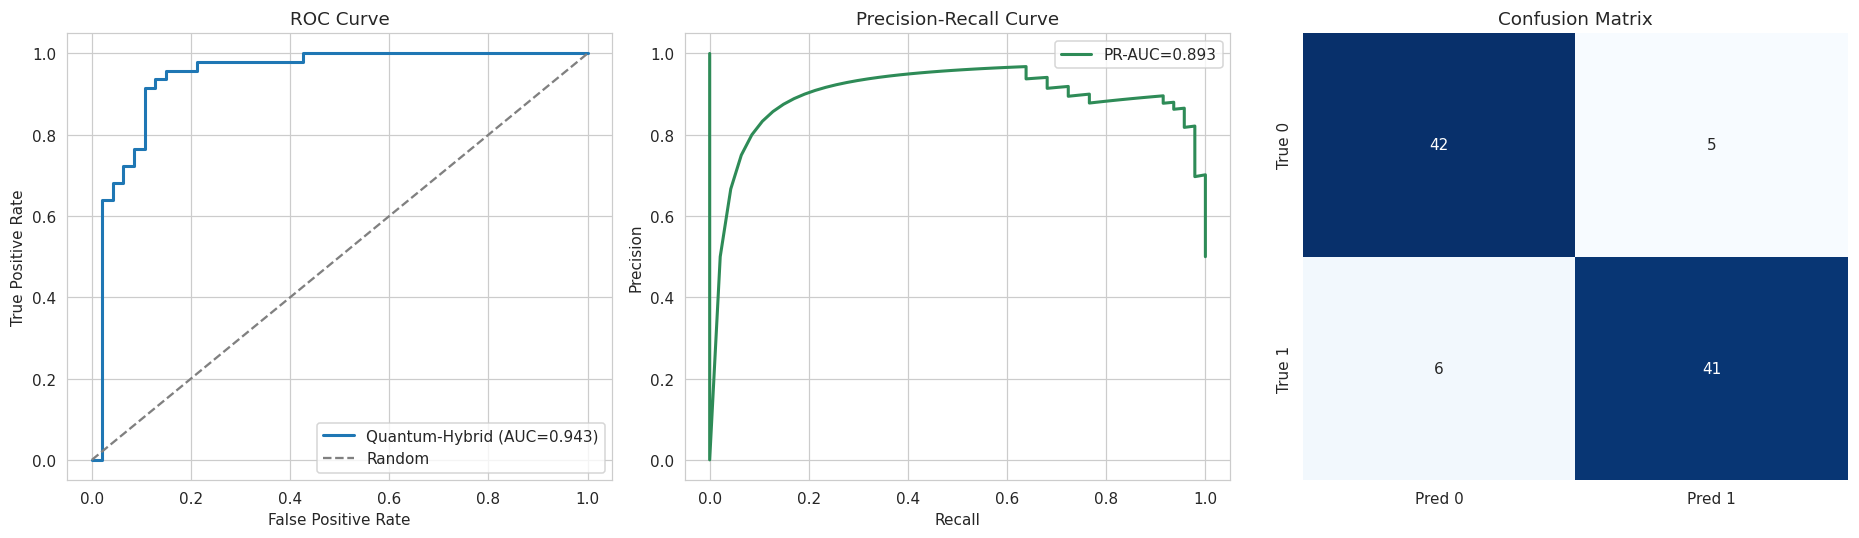

In [19]:
# ============================================
# 18. ROC CURVE, PR CURVE, CONFUSION MATRIX
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[0].plot(fpr, tpr, linewidth=2, label=f"Quantum-Hybrid (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

# Precision-Recall
prec_curve, rec_curve, _ = precision_recall_curve(test_labels, test_probs)
axes[1].plot(rec_curve, prec_curve, linewidth=2, color="seagreen", label=f"PR-AUC={pr_auc:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"], ax=axes[2])
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "roc_pr_confusion.png"))
plt.show()


## 12. Uncertainty Estimation — Monte Carlo Dropout

We keep the Dropout layers **stochastic at inference time** (`model.train()` mode, no
gradient tracking) and run `T` forward passes per sample. The mean of the stochastic
predictions is the calibrated probability estimate; their spread captures the model's
epistemic uncertainty. We report:

- **Predictive standard deviation** and **predictive entropy** as uncertainty scores
- Whether uncertainty is higher on the samples the model got **wrong**
- A reliability curve to see whether confidence tracks empirical accuracy

In [20]:
# ============================================
# 19. MONTE CARLO DROPOUT INFERENCE
# ============================================

def enable_mc_dropout(model):
    """Set the whole model to train() (so Dropout is stochastic) but freeze BatchNorm
    running statistics so batch composition doesn't leak into predictions."""
    model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm1d):
            module.eval()

T_MC_PASSES = 100

enable_mc_dropout(hybrid_model)

mc_predictions = np.zeros((T_MC_PASSES, len(X_test_t)))

with torch.no_grad():
    for t in range(T_MC_PASSES):
        mc_predictions[t] = hybrid_model(X_test_t).numpy().ravel()

hybrid_model.eval()  # back to deterministic mode for anything downstream

mc_mean = mc_predictions.mean(axis=0)
mc_std = mc_predictions.std(axis=0)

eps = 1e-9
mc_entropy = -(mc_mean * np.log(mc_mean + eps) + (1 - mc_mean) * np.log(1 - mc_mean + eps))

mc_preds_binary = (mc_mean > 0.5).astype(int)
mc_correct = (mc_preds_binary == test_labels)

mc_accuracy = accuracy_score(test_labels, mc_preds_binary)
mc_auc = roc_auc_score(test_labels, mc_mean)

print("=" * 70)
print(f"MONTE CARLO DROPOUT ({T_MC_PASSES} stochastic passes)")
print("=" * 70)
print(f"MC-averaged Accuracy : {mc_accuracy:.4f}")
print(f"MC-averaged ROC-AUC  : {mc_auc:.4f}")
print(f"Mean predictive std  : {mc_std.mean():.4f}")
print(f"Mean predictive entropy: {mc_entropy.mean():.4f}")

print(f"\nMean uncertainty (std) on CORRECT predictions : {mc_std[mc_correct].mean():.4f}")
print(f"Mean uncertainty (std) on INCORRECT predictions: {mc_std[~mc_correct].mean():.4f}")


MONTE CARLO DROPOUT (100 stochastic passes)
MC-averaged Accuracy : 0.8723
MC-averaged ROC-AUC  : 0.9425
Mean predictive std  : 0.1336
Mean predictive entropy: 0.2957

Mean uncertainty (std) on CORRECT predictions : 0.1263
Mean uncertainty (std) on INCORRECT predictions: 0.1837


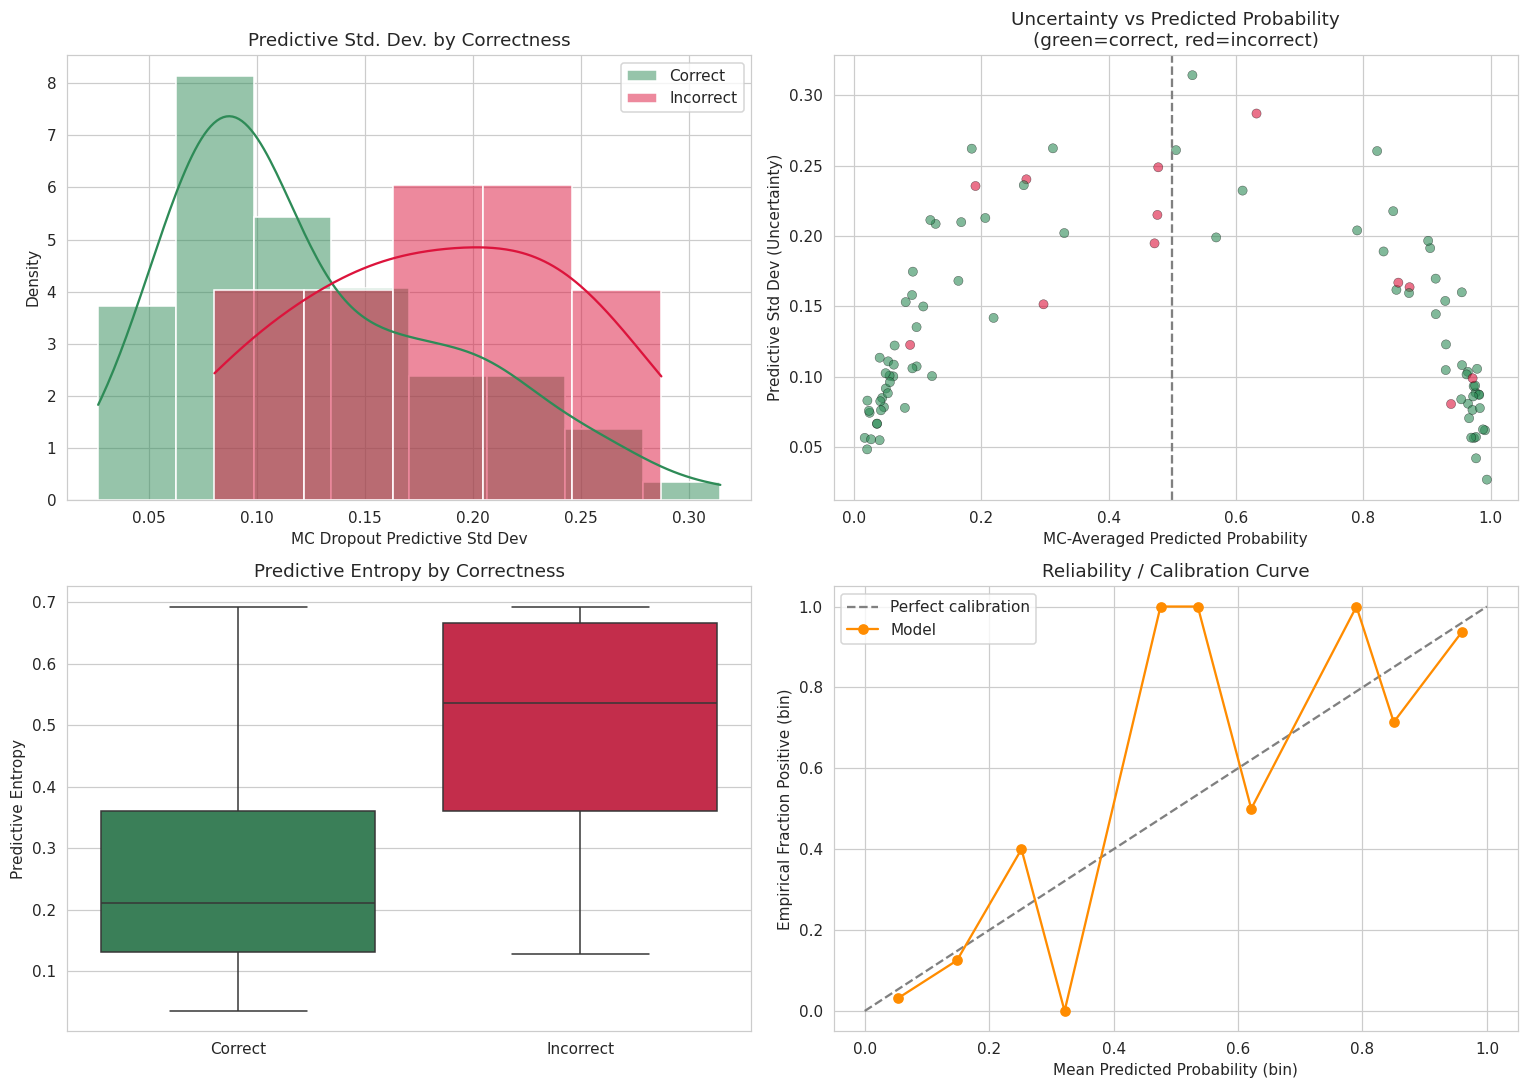

Expected Calibration Error (ECE): 0.0781


In [21]:
# ============================================
# 20. UNCERTAINTY VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Distribution of predictive std, split by correctness
sns.histplot(mc_std[mc_correct], color="seagreen", label="Correct", kde=True, ax=axes[0, 0], stat="density", alpha=0.5)
sns.histplot(mc_std[~mc_correct], color="crimson", label="Incorrect", kde=True, ax=axes[0, 0], stat="density", alpha=0.5)
axes[0, 0].set_title("Predictive Std. Dev. by Correctness")
axes[0, 0].set_xlabel("MC Dropout Predictive Std Dev")
axes[0, 0].legend()

# (b) Uncertainty (std) vs mean predicted probability, colored by correctness
colors = np.where(mc_correct, "seagreen", "crimson")
axes[0, 1].scatter(mc_mean, mc_std, c=colors, alpha=0.6, edgecolor="k", linewidth=0.3)
axes[0, 1].axvline(0.5, linestyle="--", color="gray")
axes[0, 1].set_xlabel("MC-Averaged Predicted Probability")
axes[0, 1].set_ylabel("Predictive Std Dev (Uncertainty)")
axes[0, 1].set_title("Uncertainty vs Predicted Probability\n(green=correct, red=incorrect)")

# (c) Boxplot: uncertainty (entropy) grouped by correctness
box_df = pd.DataFrame({"entropy": mc_entropy, "correct": np.where(mc_correct, "Correct", "Incorrect")})
sns.boxplot(data=box_df, x="correct", y="entropy", palette={"Correct": "seagreen", "Incorrect": "crimson"}, ax=axes[1, 0])
axes[1, 0].set_title("Predictive Entropy by Correctness")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Predictive Entropy")

# (d) Reliability / calibration curve
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_ids = np.digitize(mc_mean, bin_edges[1:-1])
bin_acc, bin_conf, bin_counts = [], [], []
for b in range(n_bins):
    mask = bin_ids == b
    if mask.sum() > 0:
        bin_acc.append(test_labels[mask].mean())
        bin_conf.append(mc_mean[mask].mean())
        bin_counts.append(mask.sum())

axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
axes[1, 1].plot(bin_conf, bin_acc, marker="o", color="darkorange", label="Model")
axes[1, 1].set_xlabel("Mean Predicted Probability (bin)")
axes[1, 1].set_ylabel("Empirical Fraction Positive (bin)")
axes[1, 1].set_title("Reliability / Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "uncertainty_analysis.png"))
plt.show()

# Expected Calibration Error (ECE)
ece = float(np.sum([abs(a - c) * (n / len(test_labels)) for a, c, n in zip(bin_acc, bin_conf, bin_counts)]))
print(f"Expected Calibration Error (ECE): {ece:.4f}")


In [22]:
# ============================================
# 21. FLAG HIGH-UNCERTAINTY PREDICTIONS FOR REVIEW
# ============================================

uncertainty_df = pd.DataFrame({
    "true_label": test_labels.astype(int),
    "predicted_label": mc_preds_binary,
    "mean_probability": mc_mean,
    "predictive_std": mc_std,
    "predictive_entropy": mc_entropy,
    "correct": mc_correct,
})

UNCERTAINTY_FLAG_QUANTILE = 0.90
std_cutoff = uncertainty_df["predictive_std"].quantile(UNCERTAINTY_FLAG_QUANTILE)
uncertainty_df["flag_for_review"] = uncertainty_df["predictive_std"] >= std_cutoff

print(f"Samples flagged for manual review (top {(1 - UNCERTAINTY_FLAG_QUANTILE) * 100:.0f}% by uncertainty): "
      f"{uncertainty_df['flag_for_review'].sum()} / {len(uncertainty_df)}")

print("\nFlagged sample summary:")
print(uncertainty_df[uncertainty_df.flag_for_review].describe())

uncertainty_df.to_csv(os.path.join(WORK_DIR, "swarsanket_qh_uncertainty_report.csv"), index=False)
print("\n✓ Uncertainty report saved.")


Samples flagged for manual review (top 10% by uncertainty): 10 / 94

Flagged sample summary:
       true_label  predicted_label  mean_probability  predictive_std  \
count   10.000000        10.000000         10.000000       10.000000   
mean     0.600000         0.400000          0.419368        0.260810   
std      0.516398         0.516398          0.209476        0.024443   
min      0.000000         0.000000          0.184742        0.235529   
25%      0.000000         0.000000          0.267545        0.242432   
50%      1.000000         0.000000          0.395039        0.260723   
75%      1.000000         1.000000          0.525019        0.262280   
max      1.000000         1.000000          0.821724        0.314370   

       predictive_entropy  
count           10.000000  
mean             0.595321  
std              0.090929  
min              0.468770  
25%              0.510302  
50%              0.602415  
75%              0.682821  
max              0.693082  

✓ Unc

## 13. Save Production Artifacts

In [23]:
# ============================================
# 22. SAVE MODEL & ALL ARTIFACTS
# ============================================

model_path = os.path.join(WORK_DIR, "swarsanket_quantum_hybrid_model.pt")
torch.save(hybrid_model.state_dict(), model_path)

config = {
    "n_qubits": N_QUBITS,
    "n_quantum_layers": N_QUANTUM_LAYERS,
    "encoder_hidden": ENCODER_HIDDEN,
    "latent_dim": LATENT_DIM,
    "decoder_hidden": DECODER_HIDDEN,
    "dropout_p": DROPOUT_P,
    "n_features": N_FEATURES,
    "selected_features": selected_features,
}
with open(os.path.join(WORK_DIR, "swarsanket_qh_model_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("=" * 70)
print("ARTIFACTS SAVED")
print("=" * 70)
for name in sorted(os.listdir(WORK_DIR)):
    path = os.path.join(WORK_DIR, name)
    if os.path.isfile(path):
        print(f"✓ {name:50s} {os.path.getsize(path):>10,} bytes")


ARTIFACTS SAVED
✓ class_distribution_before_after_smote.png              22,013 bytes
✓ class_distribution_before_smote.png                    21,368 bytes
✓ rfecv_scores.png                                       66,405 bytes
✓ roc_pr_confusion.png                                   63,626 bytes
✓ swarsanket_qh_evaluation.json                           1,322 bytes
✓ swarsanket_qh_imputer.pkl                               3,759 bytes
✓ swarsanket_qh_model_config.json                           804 bytes
✓ swarsanket_qh_scaler.pkl                                1,911 bytes
✓ swarsanket_qh_selected_features.json                      583 bytes
✓ swarsanket_qh_training_history.csv                     11,545 bytes
✓ swarsanket_qh_uncertainty_report.csv                    7,035 bytes
✓ swarsanket_quantum_hybrid_model.pt                     13,059 bytes
✓ training_curves.png                                   150,347 bytes
✓ uncertainty_analysis.png                              174,231 bytes


## 14. Final Summary

In [24]:
# ============================================
# 23. FINAL SUMMARY
# ============================================

print("=" * 75)
print("SWARSANKET — QUANTUM-HYBRID MODEL — FINAL SUMMARY")
print("=" * 75)

print(f"""
DATASET
  Training samples (pre-SMOTE)  : {len(X_train_sel)}
  Training samples (post-SMOTE) : {len(X_train_bal)}
  Validation samples            : {len(X_val_sel)}
  Held-out test samples         : {len(X_test_sel)}
  SMOTE applied                 : {needs_smote}

FEATURE SELECTION (RFECV)
  Candidate features             : {len(candidate_features)}
  Selected features               : {N_FEATURES}

MODEL
  Architecture : Classical Encoder -> {N_QUBITS}-Qubit Variational Quantum Circuit -> Classical Decoder
  Parameters   : {n_params}
  XGBoost used : No

HELD-OUT TEST PERFORMANCE
  Accuracy           : {accuracy:.4f}
  Precision           : {precision:.4f}
  Recall / Sensitivity: {recall:.4f}
  Specificity          : {specificity:.4f}
  F1-score             : {f1:.4f}
  Balanced Accuracy    : {bal_acc:.4f}
  ROC-AUC              : {roc_auc:.4f}
  PR-AUC               : {pr_auc:.4f}
  Matthews CorrCoef    : {mcc:.4f}
  Cohen's Kappa        : {kappa:.4f}
  Brier Score          : {brier:.4f}
  Log Loss             : {logloss:.4f}

UNCERTAINTY (Monte Carlo Dropout, {T_MC_PASSES} passes)
  MC-averaged accuracy : {mc_accuracy:.4f}
  MC-averaged ROC-AUC  : {mc_auc:.4f}
  Expected Calibration Error (ECE): {ece:.4f}
  Mean uncertainty on correct predictions   : {mc_std[mc_correct].mean():.4f}
  Mean uncertainty on incorrect predictions : {mc_std[~mc_correct].mean():.4f}
  Samples flagged for manual review         : {uncertainty_df['flag_for_review'].sum()} / {len(uncertainty_df)}
""")

print("=" * 75)
print("✓ Notebook complete. Artifacts written to:", WORK_DIR)
print("=" * 75)


SWARSANKET — QUANTUM-HYBRID MODEL — FINAL SUMMARY

DATASET
  Training samples (pre-SMOTE)  : 299
  Training samples (post-SMOTE) : 299
  Validation samples            : 75
  Held-out test samples         : 94
  SMOTE applied                 : False

FEATURE SELECTION (RFECV)
  Candidate features             : 91
  Selected features               : 22

MODEL
  Architecture : Classical Encoder -> 8-Qubit Variational Quantum Circuit -> Classical Decoder
  Parameters   : 777
  XGBoost used : No

HELD-OUT TEST PERFORMANCE
  Accuracy           : 0.8830
  Precision           : 0.8913
  Recall / Sensitivity: 0.8723
  Specificity          : 0.8936
  F1-score             : 0.8817
  Balanced Accuracy    : 0.8830
  ROC-AUC              : 0.9430
  PR-AUC               : 0.8931
  Matthews CorrCoef    : 0.7661
  Cohen's Kappa        : 0.7660
  Brier Score          : 0.0948
  Log Loss             : 0.3814

UNCERTAINTY (Monte Carlo Dropout, 100 passes)
  MC-averaged accuracy : 0.8723
  MC-averaged ROC-